# Simulasi Monte Carlo Non-Disjunction pada Meiosis untuk Prediksi Risiko Aneuploidi Berdasarkan Usia Maternal
**Tugas Proyek IF3211 Domain-Specific Computation**

---
## Abstrak
Notebook ini mengimplementasikan simulasi Monte Carlo untuk memprediksi peluang terjadinya
non-disjunction kromosom selama proses meiosis, berdasarkan model probabilistik usia maternal.
Dataset empiris bersumber dari literatur medis (Hook 1981, Morris et al. 2002, ACMG 2016).

**Pertanyaan Penelitian:**
> *Seberapa besar pengaruh usia maternal terhadap probabilitas terjadinya non-disjunction kromosom
> pada Meiosis I dan Meiosis II, dan bagaimana distribusinya dapat dimodelkan menggunakan simulasi Monte Carlo?*

## 1. Import Library & Setup

In [ ]:
import sys
import math
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
pd.set_option('display.float_format', '{:.6f}'.format)

projectRoot = Path().resolve()
if projectRoot.name == 'notebooks':
    projectRoot = projectRoot.parents[1]
sys.path.insert(0, str(projectRoot))


In [ ]:
from backend.src.models.risk_model import MaternalAgeRiskModel
from backend.src.simulation.monte_carlo import MeiosisMonteCarloSimulator, SimulationConfig
from backend.src.models.gamete import GameteSex
import requests

apiResponse = requests.get('http://127.0.0.1:8000/api/risk/curve?age_min=15&age_max=49', timeout=5)
apiResponse.raise_for_status()
riskCurve = apiResponse.json()['curve']
riskDf = pd.DataFrame(riskCurve)
riskTable = {int(row['maternal_age']): float(row['total_risk']) for row in riskCurve}
riskModel = MaternalAgeRiskModel(customTable=riskTable)
print(f'   Kurva risiko dimuat dari API backend: {len(riskDf)} titik data')

   Kurva risiko dimuat dari API backend: 35 titik data


## 2. Memuat Data Kurva Risiko dari Backend

### Preview Data Kurva Risiko

In [ ]:
print(f'Kurva risiko siap dipakai: {len(riskDf)} baris, {riskDf.shape[1]} kolom')
riskDf.head(10)

Kurva risiko siap dipakai: 35 baris, 7 kolom


,maternal_age,total_risk,meiosis_I_risk,meiosis_II_risk,risk_category,risk_ratio_to_base,total_risk_percent
0,15,0.002200,0.001650,0.000550,rendah,1.050000,0.220000
1,16,0.002100,0.001575,0.000525,rendah,1.000000,0.210000
2,17,0.002000,0.001500,0.000500,rendah,0.950000,0.200000
3,18,0.001900,0.001425,0.000475,rendah,0.900000,0.190000
4,19,0.001800,0.001350,0.000450,rendah,0.860000,0.180000
5,20,0.001900,0.001425,0.000475,rendah,0.900000,0.190000
6,21,0.001900,0.001425,0.000475,rendah,0.900000,0.190000
7,22,0.002000,0.001500,0.000500,rendah,0.950000,0.200000
8,23,0.002000,0.001500,0.000500,rendah,0.950000,0.200000
9,24,0.002100,0.001575,0.000525,rendah,1.000000,0.210000


### Memuat Data Referensi Sindrom

In [ ]:
apiResponse = requests.get('http://127.0.0.1:8000/api/data/syndromes', timeout=5)
apiResponse.raise_for_status()
syndromeDf = pd.DataFrame(apiResponse.json()['syndromes'])
print(f'   Data sindrom dimuat dari API backend: {len(syndromeDf)} baris')
syndromeDf


   Data sindrom dimuat dari API backend: 37 baris


,syndromeName,chromosomeAffected,type,aneuploidKaryotype,incidencePerLiveBirth,viability,primaryNdStage,maternalAgeEffect,clinicalFeatures
0,Trisomi 1,1,Trisomi Autosom,"47,XX,+1 / 47,XY,+1",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal pada tahap embrio awal, tidak pernah dil..."
1,Trisomi 2,2,Trisomi Autosom,"47,XX,+2 / 47,XY,+2",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal, ditemukan pada aborsi spontan tahap awa..."
2,Trisomi 3,3,Trisomi Autosom,"47,XX,+3 / 47,XY,+3",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal prenatal, malformasi berat seluruh siste..."
3,Trisomi 4,4,Trisomi Autosom,"47,XX,+4 / 47,XY,+4",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal, mosaik sangat jarang dilaporkan dengan ..."
4,Trisomi 5,5,Trisomi Autosom,"47,XX,+5 / 47,XY,+5",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal prenatal, kelainan jantung dan otak berat"
5,Trisomi 6,6,Trisomi Autosom,"47,XX,+6 / 47,XY,+6",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal, ditemukan pada abortus spontan, mosaik ..."
6,Trisomi 7,7,Trisomi Autosom,"47,XX,+7 / 47,XY,+7",Sangat jarang (tidak viabel),Mosaik viable,Meiosis I,Tidak ada,"Letal pada kondisi non-mosaik, mosaik: pigment..."
7,Trisomi 8 (Warkany 2),8,Trisomi Autosom,"47,XX,+8 / 47,XY,+8",1/25000-50000 (mosaik),Mosaik viable,Meiosis I/II,Tidak ada,"Letal pada kondisi non-mosaik, mosaik: disabil..."
8,Trisomi 9,9,Trisomi Autosom,"47,XX,+9 / 47,XY,+9",Sangat jarang (tidak viabel),Tidak viabel / Mosaik,Meiosis I,Tidak ada,"Letal pada kondisi non-mosaik, mosaik: microce..."
9,Trisomi 10,10,Trisomi Autosom,"47,XX,+10 / 47,XY,+10",Sangat jarang (tidak viabel),Tidak viabel,Meiosis I,Tidak ada,"Letal prenatal, ditemukan pada abortus spontan..."


### Statistik Deskriptif Dataset Risiko

In [ ]:
riskDf[['maternal_age', 'total_risk_percent', 'meiosis_I_risk', 'meiosis_II_risk']].describe()

,maternal_age,total_risk_percent,meiosis_I_risk,meiosis_II_risk
count,35.000000,35.000000,35.000000,35.000000
mean,32.000000,2.004000,0.015030,0.005010
std,10.246951,3.500495,0.026254,0.008751
min,15.000000,0.180000,0.001350,0.000450
25%,23.500000,0.210000,0.001575,0.000525
50%,32.000000,0.310000,0.002325,0.000775
75%,40.500000,1.815000,0.013612,0.004537
max,49.000000,14.930000,0.111975,0.037325


## 3. Visualisasi Data Empiris

### Plot kurva risiko vs usia 

In [ ]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Risiko Total vs Usia Maternal (Skala Linier)',
                    'Risiko Total vs Usia Maternal (Skala Log)'))

for col, yaxisType in enumerate(['linear', 'log'], start=1):
    fig.add_trace(go.Scatter(
        x=riskDf['maternal_age'], y=riskDf['total_risk_percent'],
        name='Risiko Total', mode='lines+markers',
        line=dict(color='#e74c3c', width=2),
        marker=dict(size=5)
    ), row=1, col=col)
    fig.update_yaxes(type=yaxisType, title_text='Risiko (%)', row=1, col=col)
    fig.update_xaxes(title_text='Usia Maternal (tahun)', row=1, col=col)

for col in [1, 2]:
    fig.add_vline(x=35, line_dash='dash', line_color='orange',
                  annotation_text='AMA (35th)', row=1, col=col)

fig.update_layout(
    title='Kurva Risiko Aneuploidi Berdasarkan Usia Maternal',
    height=450, template='plotly_dark', showlegend=True
)
fig.show()

## 4. Implementasi Model Probabilistik & Monte Carlo

### Tabel Profil Risiko per Kelompok Usia

In [ ]:
agesOfInterest = [20, 25, 30, 35, 38, 40, 42, 45]
riskProfiles = [riskModel.getRiskProfile(age).toDict() for age in agesOfInterest]
riskProfileDf = pd.DataFrame(riskProfiles)
riskProfileDf[['maternal_age', 'total_risk_percent', 'meiosis_I_risk',
               'meiosis_II_risk', 'risk_category', 'risk_ratio_to_base']]

,maternal_age,total_risk_percent,meiosis_I_risk,meiosis_II_risk,risk_category,risk_ratio_to_base
0,20,0.190000,0.001425,0.000475,rendah,0.900000
1,25,0.210000,0.001575,0.000525,rendah,1.000000
2,30,0.260000,0.001950,0.000650,rendah,1.240000
3,35,0.560000,0.004200,0.001400,sedang,2.670000
4,38,0.950000,0.007125,0.002375,sedang,4.520000
5,40,1.580000,0.011850,0.003950,sedang,7.520000
6,42,2.550000,0.019125,0.006375,tinggi,12.140000
7,45,5.370000,0.040275,0.013425,tinggi,25.570000


### Simulasi Monte Carlo — Usia 35 Tahun

In [ ]:
# Konfigurasi: 10.000 iterasi, fokus kromosom 21 (Down syndrome)
config35 = SimulationConfig(
    maternalAge=35,
    nSimulations=10_000,
    targetChromosome=21,
    gameteSex=GameteSex.EGG,
    randomSeed=42
)
sim35 = MeiosisMonteCarloSimulator(config35, riskModel)
result35 = sim35.run()

print('=== Hasil Simulasi Monte Carlo — Usia 35 tahun ===')
print(f'  Total iterasi       : {result35.totalRuns:,}')
print(f'  Gamet aneuploid     : {result35.aneuploidCount:,}')
print(f'  Risiko observasi    : {result35.observedRisk*100:.4f}%')
print(f'  Risiko model        : {result35.modelRisk*100:.4f}%')
print(f'  ND Meiosis I        : {result35.ndMeiosisICount:,}')
print(f'  ND Meiosis II       : {result35.ndMeiosisIICount:,}')
print(f'  Waktu eksekusi      : {result35.executionTimeMs:.1f} ms')
print(f'\n  Distribusi Sindrom  :')
for syndrome, count in result35.syndromeCounts.items():
    print(f'    - {syndrome}: {count}')


=== Hasil Simulasi Monte Carlo — Usia 35 tahun ===
  Total iterasi       : 10,000
  Gamet aneuploid     : 54
  Risiko observasi    : 0.5400%
  Risiko model        : 0.5600%
  ND Meiosis I        : 34
  ND Meiosis II       : 20
  Waktu eksekusi      : 1149.4 ms

  Distribusi Sindrom  :
    - Trisomi 21 (Sindrom Down): 54


### Age Sweep: Simulasi Usia 20–45 Tahun

In [ ]:
# Setiap usia disimulasikan 1.000 iterasi untuk mendapatkan tren risiko
print('Menjalankan age sweep simulasi (20–45 tahun)...')
configSweep = SimulationConfig(nSimulations=1000, maternalAge=20, randomSeed=0)
simulatorSweep = MeiosisMonteCarloSimulator(configSweep, riskModel)
sweepData = simulatorSweep.runAgeSweep(ageRange=(20, 45))

sweepDf = pd.DataFrame(sweepData)
print(f'Selesai. {len(sweepDf)} titik data.')
sweepDf.head()


Menjalankan age sweep simulasi (20–45 tahun)...
Selesai. 26 titik data.


,age,observed_risk,model_risk,aneuploid_count,total_runs
0,20,0.010000,0.001900,1,100
1,21,0.010000,0.001900,1,100
2,22,0.010000,0.002000,1,100
3,23,0.010000,0.002000,1,100
4,24,0.010000,0.002100,1,100


### Grafik Validasi: Risiko Observasi vs Model Teoritis

In [ ]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sweepDf['age'], y=sweepDf['observed_risk'] * 100, 
    name='Risiko Observasi (Monte Carlo)',
    mode='markers+lines', line=dict(color='#e74c3c', dash='dot'),
    marker=dict(size=6)
))
fig.add_trace(go.Scatter(
    x=sweepDf['age'], y=sweepDf['model_risk'] * 100,  
    name='Risiko Teoritis (Model Probabilistik)',
    mode='lines', line=dict(color='#2ecc71', width=2.5)
))
fig.add_vline(x=35, line_dash='dash', line_color='orange', annotation_text='AMA Threshold (35)')
fig.update_layout(
    title='Validasi: Risiko Observasi Monte Carlo vs Model Teoritis',
    xaxis_title='Usia Maternal (tahun)', yaxis_title='Probabilitas Aneuploidi (%)',
    template='plotly_dark', height=420
)
fig.show()

## 5. Analisis Statistik & Validasi Model

### Distribusi Sindrom

In [ ]:
if result35.syndromeCounts:
    syndromeDf = pd.DataFrame([
        {'sindrom': k, 'jumlah': v}
        for k, v in result35.syndromeCounts.items()
    ]).sort_values('jumlah', ascending=False)

    figSyn = px.bar(
        syndromeDf, x='sindrom', y='jumlah',
        title=f'Distribusi Prediksi Sindrom (Usia 35, n={result35.totalRuns:,})',
        color='jumlah', color_continuous_scale='Reds',
        template='plotly_dark'
    )
    figSyn.show()
else:
    print('Tidak ada gamet aneuploid yang terdeteksi pada simulasi ini.')


### Wilson Confidence Interval & Validasi Model

In [ ]:
from backend.src.simulation.statistics import SimulationStatisticsAnalyzer

statisticsAnalyzer = SimulationStatisticsAnalyzer([])
ci = statisticsAnalyzer.wilsonConfidenceInterval(
    successes=result35.aneuploidCount,
    n=result35.totalRuns,
    confidence=0.95
)
print('=== 95% Wilson Score Confidence Interval ===')
print(f'  Proporsi observasi : {ci.center*100:.4f}%')
print(f'  CI Lower           : {ci.lower*100:.4f}%')
print(f'  CI Upper           : {ci.upper*100:.4f}%')
print(f'  Margin of Error    : ±{ci.toDict()["margin_of_error"]*100:.4f}%')

# Perbandingan observasi vs model
comparison = statisticsAnalyzer.compareObservedVsModel(
    observed=result35.observedRisk,
    model=result35.modelRisk,
    n=result35.totalRuns
)
print('\n=== Validasi Model ===')
for key, value in comparison.items():
    print(f'  {key}: {value}')

=== 95% Wilson Score Confidence Interval ===
  Proporsi observasi : 0.5400%
  CI Lower           : 0.4141%
  CI Upper           : 0.7039%
  Margin of Error    : ±0.1449%

=== Validasi Model ===
  observedRisk: 0.0054
  modelRisk: 0.0056
  absoluteDifference: 0.0002
  relativeDifferencePercent: 3.57
  nSimulations: 10000
  interpretation: Simulasi konvergen dengan model teoritis (perbedaan < 10%)


### Relative Risk: Usia 35 vs 25

In [ ]:
relativeRisk = statisticsAnalyzer.relativeRisk(
    riskExposed=result35.modelRisk,
    riskBaseline=riskModel.getRiskProfile(25).totalRisk
)
print(f'Relative Risk (usia 35 vs 25): {relativeRisk:.2f}x')
print(f'→ Wanita usia 35 memiliki risiko {relativeRisk:.1f}x lebih tinggi dari usia 25')


Relative Risk (usia 35 vs 25): 2.67x
→ Wanita usia 35 memiliki risiko 2.7x lebih tinggi dari usia 25


### Heatmap Distribusi Non-Disjunction per Usia

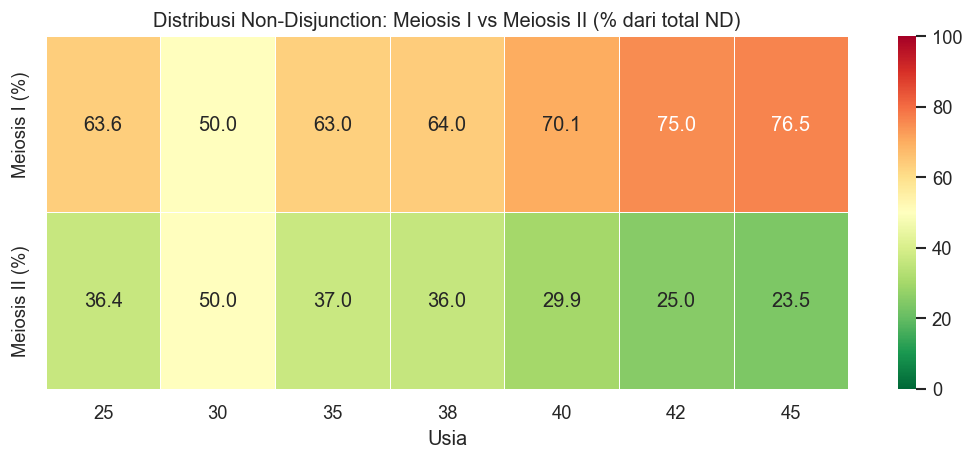

In [ ]:
# Heatmap: Meiosis I vs II per usia
agesOfInterest = [25, 30, 35, 38, 40, 42, 45]
ndData = []
for age in agesOfInterest:
    config = SimulationConfig(maternalAge=age, nSimulations=10000, randomSeed=42)
    simulationResult = MeiosisMonteCarloSimulator(config, riskModel).run()
    totalNd = simulationResult.ndMeiosisICount + simulationResult.ndMeiosisIICount
    ndData.append({
        'Usia': age,
        'Meiosis I (%)': simulationResult.ndMeiosisICount / totalNd * 100 if totalNd > 0 else 0,
        'Meiosis II (%)': simulationResult.ndMeiosisIICount / totalNd * 100 if totalNd > 0 else 0,
    })

dfNd = pd.DataFrame(ndData).set_index('Usia')
plt.figure(figsize=(9, 4))
sns.heatmap(dfNd.T, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5, vmin=0, vmax=100)
plt.title('Distribusi Non-Disjunction: Meiosis I vs Meiosis II (% dari total ND)')
plt.tight_layout()
plt.show()


## 6. Sampel Gamet Aneuploid (Data untuk Visualisasi 3D)

In [ ]:
# Cetak detail gamet aneuploid sampel
# Data ini akan dikirim ke Three.js untuk visualisasi 3D
print(f'Total sampel gamet aneuploid: {len(result35.sampleGametes)}')
for index, gamete in enumerate(result35.sampleGametes, 1):
    gameteData = gamete.toDict()
    print(f'\n  [{index}] Gamet ID   : {gameteData["gamete_id"]}')
    print(f'      Jumlah Chr  : {gameteData["chromosome_count"]}')
    print(f'      Sindrom     : {gameteData["predicted_syndrome"]}')
    print(f'      Chr terdampak: {[c["label"] for c in gameteData["affected_chromosomes"]]}')

Total sampel gamet aneuploid: 5

  [1] Gamet ID   : egg_101640
      Jumlah Chr  : 24
      Sindrom     : Trisomi 21 (Sindrom Down)
      Chr terdampak: ['chr21p', 'chr21m']

  [2] Gamet ID   : egg_939030
      Jumlah Chr  : 24
      Sindrom     : Trisomi 21 (Sindrom Down)
      Chr terdampak: ['chr21p', 'chr21m']

  [3] Gamet ID   : egg_991613
      Jumlah Chr  : 24
      Sindrom     : Trisomi 21 (Sindrom Down)
      Chr terdampak: ['chr21p', 'chr21p_dup']

  [4] Gamet ID   : egg_671540
      Jumlah Chr  : 24
      Sindrom     : Trisomi 21 (Sindrom Down)
      Chr terdampak: ['chr21m', 'chr21m_dup']

  [5] Gamet ID   : egg_695451
      Jumlah Chr  : 24
      Sindrom     : Trisomi 21 (Sindrom Down)
      Chr terdampak: ['chr21p', 'chr21m']


## 7. Kesimpulan

Berdasarkan hasil simulasi Monte Carlo, model probabilistik yang digunakan mampu merepresentasikan hubungan antara usia maternal dan risiko terjadinya aneuploidi. Dari eksperimen yang dilakukan, diperoleh beberapa hasil utama sebagai berikut:

1. **Risiko aneuploidi meningkat seiring bertambahnya usia maternal**  
   Pada usia 25 tahun, risiko total aneuploidi berada di sekitar 0.21%, kemudian meningkat menjadi 0.56% pada usia 35 tahun dan mencapai 14.93% pada usia 49 tahun. Peningkatan ini menunjukkan bahwa usia maternal memiliki pengaruh yang signifikan terhadap kemungkinan terjadinya nondisjunction.

2. **Nondisjunction Meiosis I lebih sering terjadi dibanding Meiosis II**  
   Hasil simulasi menunjukkan proporsi kejadian Meiosis I cenderung lebih dominan, terutama pada usia maternal yang lebih tinggi. Temuan ini juga sesuai dengan referensi biologis yang digunakan dalam model.

3. **Hasil simulasi mendekati nilai teoritis**  
   Pada simulasi usia 35 tahun dengan 10.000 iterasi, risiko observasi sebesar 0.54% cukup dekat dengan risiko teoritis sebesar 0.56%, sehingga model dapat dianggap cukup stabil dan valid untuk digunakan dalam simulasi risiko aneuploidi.

4. **Usia 35 tahun memiliki risiko lebih tinggi dibanding usia 25 tahun**  
   Berdasarkan perhitungan *relative risk*, wanita usia 35 tahun memiliki risiko sekitar 2.67 kali lebih besar dibanding usia 25 tahun untuk menghasilkan gamet aneuploid.

### Saran Pengembangan

Beberapa pengembangan yang dapat dilakukan pada penelitian selanjutnya antara lain:

- Menambahkan faktor lain seperti riwayat keluarga, kondisi kesehatan, atau faktor lingkungan agar model prediksi menjadi lebih realistis.
- Menggunakan data klinis nyata, seperti hasil NIPT atau CVS, untuk validasi tambahan.
- Mengembangkan simulasi biologis yang lebih detail terkait mekanisme nondisjunction pada proses meiosis.
- Memperluas simulasi ke seluruh pasangan kromosom agar profil aneuploidi yang dihasilkan menjadi lebih lengkap.